In [19]:
import sys
sys.path.insert(0, '..')

# =====================================================
# EXPLORATORY ANALYSIS: METRICS OVER TIME
# =====================================================
# This notebook analyzes how metrics changes over time
# for different player types, with 95% confidence intervals.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Import utility functions from plot_utilities
from plot_utilities import (
    load_turn_data,
    setup_notebook_display,
    plot_bar_chart,
    plot_forest_plot,
    prepare_coefficient_data,
    plot_metric_over_time  # Generalized function for any metric
)

# Set up notebook display and plotting style
setup_notebook_display(figsize=(12, 6))

# Load turn data with player type mapping automatically applied
turn_df = load_turn_data('../models/output/grouped_mlp_predictions.csv', condition_exclude=[])

d:\Cache\Onedrive - Arizona\OneDrive - University of Arizona\Vox Deorum\nlp-2026-tiny-4player\analysis\performance\..\plot_utilities.py:422: DtypeWarning: Columns (45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✓ Loaded turn data: 1491128 rows
✓ Filters applied: condition_exclude=[]
✓ Unique conditions: 14
✓ Unique player types: 15
✓ Turn range: 0 - 500
✓ Unique civilizations: 43

Player Type Distribution:
  Vanilla: 935364 rows (62.7%)
  GLM-4.7-Simple: 75725 rows (5.1%)
  GLM-4.7-Briefed: 75725 rows (5.1%)
  Kimi-K2.5-Simple: 55451 rows (3.7%)
  Kimi-K2.5-Briefed: 55451 rows (3.7%)
  GPT-OSS-120B-Briefed: 54736 rows (3.7%)
  GPT-OSS-120B-Simple: 54736 rows (3.7%)
  Deepseek-3.2-Briefed: 49080 rows (3.3%)
  Deepseek-3.2-Simple: 49080 rows (3.3%)
  Minimax-M2.5-Simple: 24508 rows (1.6%)
  Minimax-M2.5-Briefed: 24508 rows (1.6%)
  Sonnet-4.5-Simple: 11192 rows (0.8%)
  Sonnet-4.5-Briefed: 11192 rows (0.8%)
  Qwen-3.5-Briefed: 7190 rows (0.5%)
  Qwen-3.5-Simple: 7190 rows (0.5%)

Condition Distribution:
  observe-vanilla-standard: 656064 rows (44.0%)
  2026-deepseek-v-kimi2-v-glm-standard: 281688 rows (18.9%)
  2026-oss-v-glm-standard: 223776 rows (15.0%)
  2026-deepseek-v-kimi2-v-minimax-stand

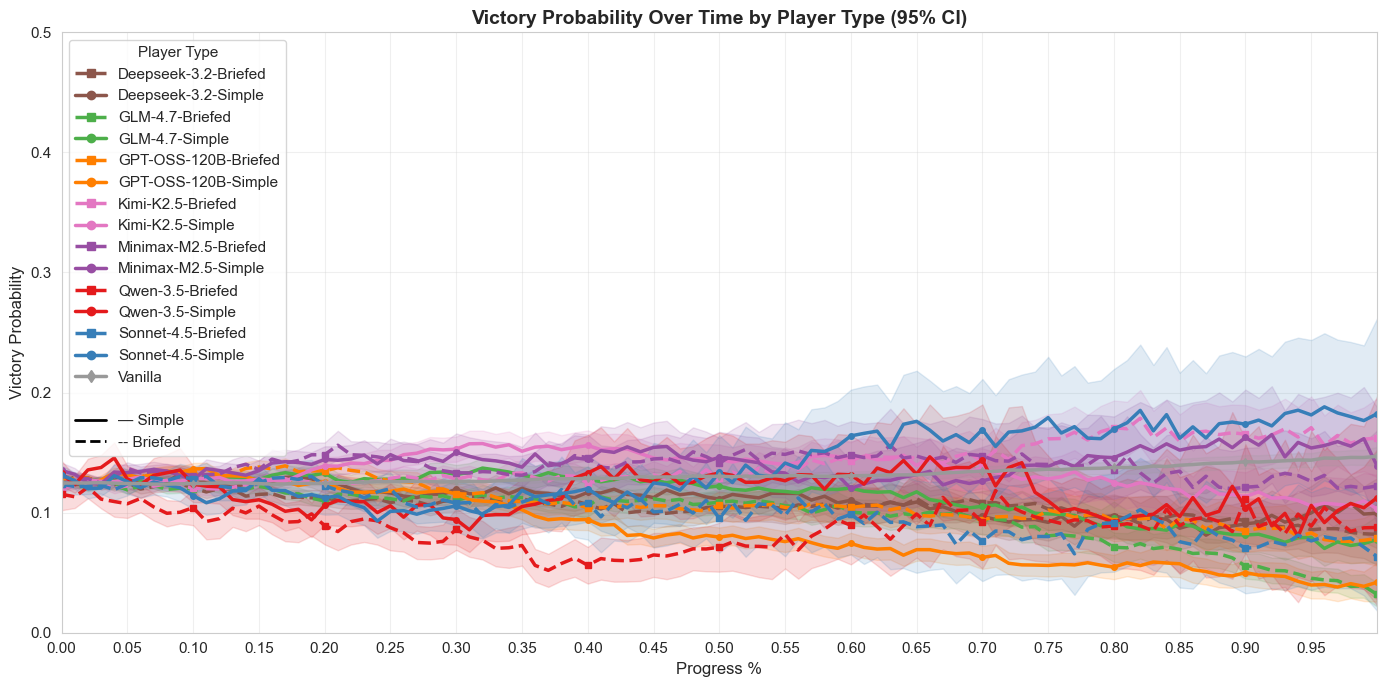

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,49080,0.106,0.151,0.0,0.998,-0.031253,-0.060
Deepseek-3.2-Simple,49080,0.110,0.154,0.0,1.000,-0.039419,-0.074
GLM-4.7-Briefed,75725,0.098,0.134,0.0,1.000,-0.074030,-0.159
GLM-4.7-Simple,75725,0.114,0.151,0.0,1.000,-0.058726,-0.112
GPT-OSS-120B-Briefed,54736,0.108,0.155,0.0,0.989,-0.055428,-0.104
GPT-OSS-120B-Simple,54736,0.086,0.107,0.0,0.963,-0.103834,-0.280
Kimi-K2.5-Briefed,55451,0.140,0.187,0.0,1.000,0.053387,0.083
Kimi-K2.5-Simple,55451,0.135,0.169,0.0,1.000,-0.020799,-0.036
Minimax-M2.5-Briefed,24508,0.139,0.190,0.0,0.996,-0.005539,-0.008
Minimax-M2.5-Simple,24508,0.142,0.198,0.0,1.000,0.015020,0.022


In [20]:
fig, ax = plot_metric_over_time(
    turn_df,
    metric_calculation=lambda df: df['predicted_win_probability'],
    title="Victory Probability Over Time by Player Type",
    ylabel="Victory Probability",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, 0.5)
)

In [21]:
# =====================================================
# PLAYER STRENGTH: QUADRATIC WEIGHTED AVERAGE
# =====================================================
# Calculate player strength using quadratic weights that emphasize late-game performance
# Uses log-odds transformation for averaging to handle extreme probabilities properly

# Define logit and inverse logit transformations
def logit(p):
    """Transform probability to log-odds space"""
    # Clip to avoid log(0) or log of negative numbers
    p_clipped = np.clip(p, 1e-5, 1 - 1e-5)
    return np.log(p_clipped / (1 - p_clipped))

def inv_logit(x):
    """Transform log-odds back to probability space"""
    return 1 / (1 + np.exp(-x))


# First, average log-odds within each turn_progress group
# This handles cases where multiple turns have the same rounded turn_progress value
turn_progress_avg = turn_df[turn_df['turn_progress'] > 0.2].groupby(['game_id', 'player_id', 'turn_progress']).agg({
    'predicted_win_probability': 'mean',
    'player_type': 'first',
    'experiment': 'first',
    'is_winner': 'last',
    'civilization': 'first'
}).reset_index()
# Calculate weights based on unique turn_progress values
# Weight = turn_progress, where turn_progress ranges from 0 to 1
turn_progress_avg['quadratic_weight'] = turn_progress_avg['turn_progress']

# Calculate weighted average of log-odds for each player
weighted_strength = []

for (game_id, player_id), group in turn_progress_avg.groupby(['game_id', 'player_id']):
    # Calculate weighted average across unique turn_progress values in
    weights = group['quadratic_weight']
    probability = group['predicted_win_probability']
    weighted_avg_probability = (weights * probability).sum() / weights.sum()
    
    # Get player type and other info
    player_type = group['player_type'].iloc[0]
    civilization = group['civilization'].iloc[0]
    experiment = group['experiment'].iloc[0]
    is_winner = group['is_winner'].iloc[-1]  # Winner status from final turn
    
    weighted_strength.append({
        'game_id': game_id,
        'player_id': player_id,
        'player_type': player_type,
        'civilization': civilization,
        'experiment': experiment,
        'weighted_strength': weighted_avg_probability,
        'is_winner': is_winner
    })

strength_df = pd.DataFrame(weighted_strength)

In [22]:
# =====================================================
# RELATIVE STRENGTH: STRENGTH RELATIVE TO GAME LEADER
# =====================================================
# Calculate each player's strength relative to the strongest player in their game

# For each game, find the maximum weighted strength
game_max_strength = strength_df.groupby('game_id')['weighted_strength'].max().reset_index()
game_max_strength.columns = ['game_id', 'max_weighted_strength']

# Merge back with the strength dataframe
strength_df = strength_df.merge(game_max_strength, on='game_id')

# Calculate relative strength as a ratio
strength_df['relative_strength'] = strength_df['weighted_strength'] / strength_df['max_weighted_strength']

player_level = strength_df.groupby(['player_type']).agg({
    'player_type': 'first',
    'relative_strength': 'mean',
})
print(player_level)

                               player_type  relative_strength
player_type                                                  
Deepseek-3.2-Briefed  Deepseek-3.2-Briefed           0.201909
Deepseek-3.2-Simple    Deepseek-3.2-Simple           0.194423
GLM-4.7-Briefed            GLM-4.7-Briefed           0.169500
GLM-4.7-Simple              GLM-4.7-Simple           0.193134
GPT-OSS-120B-Briefed  GPT-OSS-120B-Briefed           0.186806
GPT-OSS-120B-Simple    GPT-OSS-120B-Simple           0.139050
Kimi-K2.5-Briefed        Kimi-K2.5-Briefed           0.291806
Kimi-K2.5-Simple          Kimi-K2.5-Simple           0.256723
Minimax-M2.5-Briefed  Minimax-M2.5-Briefed           0.251013
Minimax-M2.5-Simple    Minimax-M2.5-Simple           0.263041
Qwen-3.5-Briefed          Qwen-3.5-Briefed           0.179440
Qwen-3.5-Simple            Qwen-3.5-Simple           0.213435
Sonnet-4.5-Briefed      Sonnet-4.5-Briefed           0.177035
Sonnet-4.5-Simple        Sonnet-4.5-Simple           0.303632
Vanilla 

In [23]:
winner_df = strength_df[strength_df['is_winner'] == 1]

# Display summary statistics
print(f"Winner's Strength Statistics:")
print(f"  Mean: {winner_df['relative_strength'].mean():.3f}")
print(f"  Median: {winner_df['relative_strength'].median():.3f}")
print(f"  Std Dev: {winner_df['relative_strength'].std():.3f}")
print(f"  Min: {winner_df['relative_strength'].min():.3f}")
print(f"  Max: {winner_df['relative_strength'].max():.3f}")

Winner's Strength Statistics:
  Mean: 0.884
  Median: 1.000
  Std Dev: 0.245
  Min: 0.027
  Max: 1.000


In [24]:
# =====================================================
# OUTLIERS: WINNERS WITH MINIMAL RELATIVE STRENGTH
# =====================================================
# Display winners who won despite having low relative strength (underdogs)

print("\n" + "=" * 60)
print("OUTLIERS: Winners with Minimal Relative Strength")
print("=" * 60)

winner_df = strength_df[strength_df['is_winner'] == 1]
# Get bottom 10 winners by relative strength
outliers = winner_df.nsmallest(10, 'relative_strength')[
    ['game_id', 'player_id', 'player_type', 'civilization', 'experiment', 
     'relative_strength', 'weighted_strength', 'max_weighted_strength']
].reset_index(drop=True)

# Display with formatted output
print(f"\nTop 10 'Underdog' Winners (lowest relative strength):\n")
for idx, row in outliers.iterrows():
    print(f"{idx+1}. Game {row['game_id']}, Player {row['player_id']}")
    print(f"   Player Type: {row['player_type']}")
    print(f"   Civilization: {row['civilization']}")
    print(f"   Experiment: {row['experiment']}")
    print(f"   Relative Strength: {row['relative_strength']:.3f}")
    print(f"   Weighted Strength: {row['weighted_strength']:.4f}")
    print(f"   Game Leader Strength: {row['max_weighted_strength']:.4f}")
    print()


OUTLIERS: Winners with Minimal Relative Strength

Top 10 'Underdog' Winners (lowest relative strength):

1. Game 567c5b26-a371-47b4-b68a-b5056c806696, Player 5
   Player Type: Vanilla
   Civilization: Germany
   Experiment: observe-vanilla-standard
   Relative Strength: 0.027
   Weighted Strength: 0.0169
   Game Leader Strength: 0.6166

2. Game ff11198e-eac8-4f33-80bd-a7b2ca975dc0, Player 4
   Player Type: GPT-OSS-120B-Simple
   Civilization: Germany
   Experiment: 2026-staff-standard
   Relative Strength: 0.031
   Weighted Strength: 0.0229
   Game Leader Strength: 0.7365

3. Game c6817e9a-d305-43ee-9648-d15a7eca8009, Player 1
   Player Type: Vanilla
   Civilization: Spain
   Experiment: observe-vanilla-standard
   Relative Strength: 0.059
   Weighted Strength: 0.0368
   Game Leader Strength: 0.6288

4. Game f051d432-aab6-4a4e-8c73-4c713fc940ca, Player 7
   Player Type: Vanilla
   Civilization: Egypt
   Experiment: observe-vanilla-standard
   Relative Strength: 0.095
   Weighted Stren

In [25]:
# Adjust all winners to have relative_strength = 0.0 (The best)

# For each winner, set relative_strength to 1.0 and adjust weighted_strength
for idx, row in strength_df[strength_df['is_winner'] == 1].iterrows():
    if row['relative_strength'] < 1.0:
        # Update weighted_strength to maintain consistency (+0.001 to make sure it is ranked #1)
        strength_df.at[idx, 'weighted_strength'] = row['max_weighted_strength'] + 0.001
        strength_df.at[idx, 'relative_strength'] = 1.0

player_level = strength_df.groupby(['player_type']).agg({
    'player_type': 'first',
    'relative_strength': 'mean',
})
print(player_level)

                               player_type  relative_strength
player_type                                                  
Deepseek-3.2-Briefed  Deepseek-3.2-Briefed           0.201909
Deepseek-3.2-Simple    Deepseek-3.2-Simple           0.199970
GLM-4.7-Briefed            GLM-4.7-Briefed           0.172195
GLM-4.7-Simple              GLM-4.7-Simple           0.197060
GPT-OSS-120B-Briefed  GPT-OSS-120B-Briefed           0.197153
GPT-OSS-120B-Simple    GPT-OSS-120B-Simple           0.162708
Kimi-K2.5-Briefed        Kimi-K2.5-Briefed           0.312233
Kimi-K2.5-Simple          Kimi-K2.5-Simple           0.260985
Minimax-M2.5-Briefed  Minimax-M2.5-Briefed           0.261792
Minimax-M2.5-Simple    Minimax-M2.5-Simple           0.279921
Qwen-3.5-Briefed          Qwen-3.5-Briefed           0.231836
Qwen-3.5-Simple            Qwen-3.5-Simple           0.213435
Sonnet-4.5-Briefed      Sonnet-4.5-Briefed           0.177035
Sonnet-4.5-Simple        Sonnet-4.5-Simple           0.328066
Vanilla 

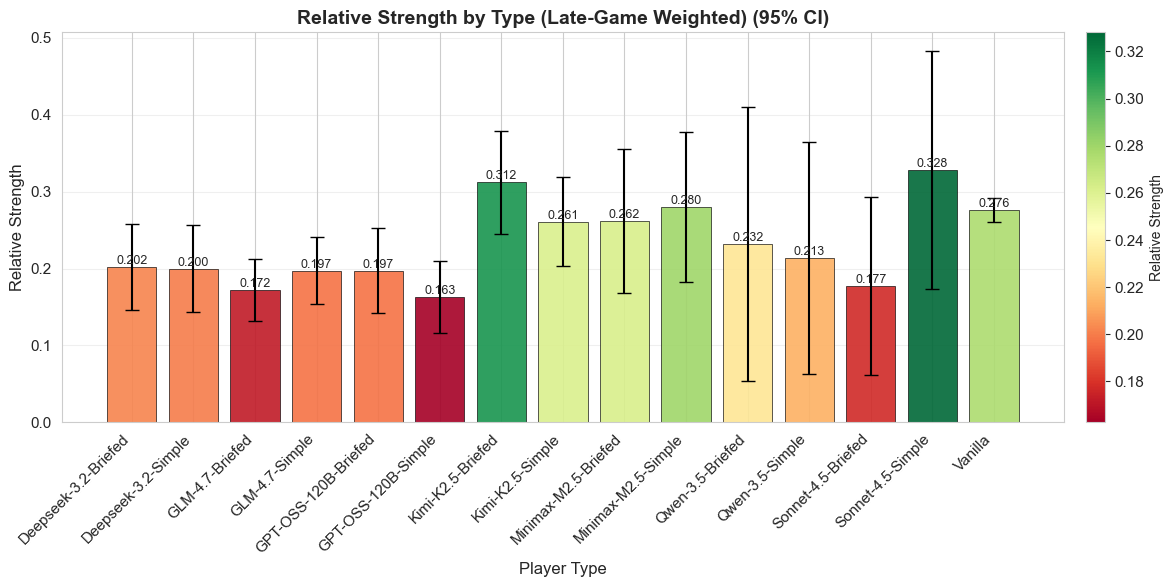

,Mean,Std,N
Deepseek-3.2-Briefed,0.201909,0.307312,115
Deepseek-3.2-Simple,0.199970,0.307265,115
GLM-4.7-Briefed,0.172195,0.274122,179
GLM-4.7-Simple,0.197060,0.297391,179
GPT-OSS-120B-Briefed,0.197153,0.320956,130
GPT-OSS-120B-Simple,0.162708,0.271943,130
Kimi-K2.5-Briefed,0.312233,0.390436,130
Kimi-K2.5-Simple,0.260985,0.335632,130
Minimax-M2.5-Briefed,0.261792,0.364313,58
Minimax-M2.5-Simple,0.279921,0.380355,58


In [26]:
# Plot bar chart of average relative strength by player type
plot_bar_chart(
    strength_df,
    category_col='player_type',
    value_col='relative_strength',
    use_percentage=False,
    xlabel='Player Type',
    ylabel='Relative Strength',
    title='Relative Strength by Type (Late-Game Weighted)',
    show_error_bars=True,
    confidence_level=0.95,
    value_format='{:.3f}',
    rotation=45,
    colormap='RdYlGn',
    figsize=(12, 6)
)

In [27]:
# =====================================================
# FIT LINEAR REGRESSION MODEL
# =====================================================
# This section fits the main linear regression model using statsmodels.
# The model includes fixed effects for players, civilizations, and conditions.

import statsmodels.api as sm
from statsmodels.formula.api import ols
from patsy.contrasts import Sum

print("=" * 60)
print("LINEAR REGRESSION: relative_strength")
print("=" * 60)

# Model specification with treatment coding for conditions and deviation coding for civilizations
# Vanilla Game (no LLM strategist) serves as the baseline for conditions
# Deviation coding (Sum) for civilizations centers effects around the mean
formula = 'relative_strength ~ C(civilization, Sum) + C(player_type, Treatment(reference="Vanilla"))'
model = ols(formula, data=strength_df).fit()

print("\nModel: Player ID, Civilization, and Condition Fixed Effects")
print("Baseline category for condition: Vanilla Game")
print("Civilization coding: Deviation (Sum) - effects relative to mean")
print(model.summary())

LINEAR REGRESSION: relative_strength

Model: Player ID, Civilization, and Condition Fixed Effects
Baseline category for condition: Vanilla Game
Civilization coding: Deviation (Sum) - effects relative to mean
                            OLS Regression Results                            
Dep. Variable:      relative_strength   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     8.612
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           6.96e-64
Time:                        12:22:04   Log-Likelihood:                -1142.0
No. Observations:                3528   AIC:                             2398.
Df Residuals:                    3471   BIC:                             2750.
Df Model:                          56                                         
Covariance Type:            nonrobust                                         
  

In [28]:
# =====================================================
# PREPARE DATA FOR VISUALIZATION
# =====================================================
# Extract coefficients and prepare data for forest plots using utility functions

# Get model results
params = model.params
conf_int = model.conf_int()
pvalues = model.pvalues

# Extract and prepare condition effects (LLM strategist)
condition_vars = [col for col in params.index if 'player_type' in col and col != 'Intercept']
condition_df = prepare_coefficient_data(params, conf_int, pvalues, condition_vars, var_type='condition')

# Extract and prepare civilization effects
civ_vars = [col for col in params.index if 'civilization' in col]
civ_df = prepare_coefficient_data(params, conf_int, pvalues, civ_vars, var_type='civilization')


Effect of LLM Strategist on Relative Strength
(95% Confidence Intervals) SUMMARY

Baseline: (Vanilla baseline)

Statistically Significant Effects (p < 0.05):
----------------------------------------
  Deepseek-3.2-Briefed           -0.073 [-0.137, -0.009] *
  Deepseek-3.2-Simple            -0.076 [-0.140, -0.012] *
  GLM-4.7-Briefed                -0.098 [-0.150, -0.046] ***
  GLM-4.7-Simple                 -0.077 [-0.129, -0.025] **
  GPT-OSS-120B-Briefed           -0.083 [-0.143, -0.023] **
  GPT-OSS-120B-Simple            -0.104 [-0.164, -0.044] ***

Non-Significant Effects:
----------------------------------------
  Kimi-K2.5-Briefed              +0.044 [-0.016, +0.104]
  Kimi-K2.5-Simple               -0.036 [-0.096, +0.024]
  Minimax-M2.5-Briefed           -0.006 [-0.095, +0.082]
  Minimax-M2.5-Simple            +0.003 [-0.085, +0.092]
  Qwen-3.5-Briefed               +0.011 [-0.151, +0.174]
  Qwen-3.5-Simple                -0.029 [-0.191, +0.133]
  Sonnet-4.5-Briefed           

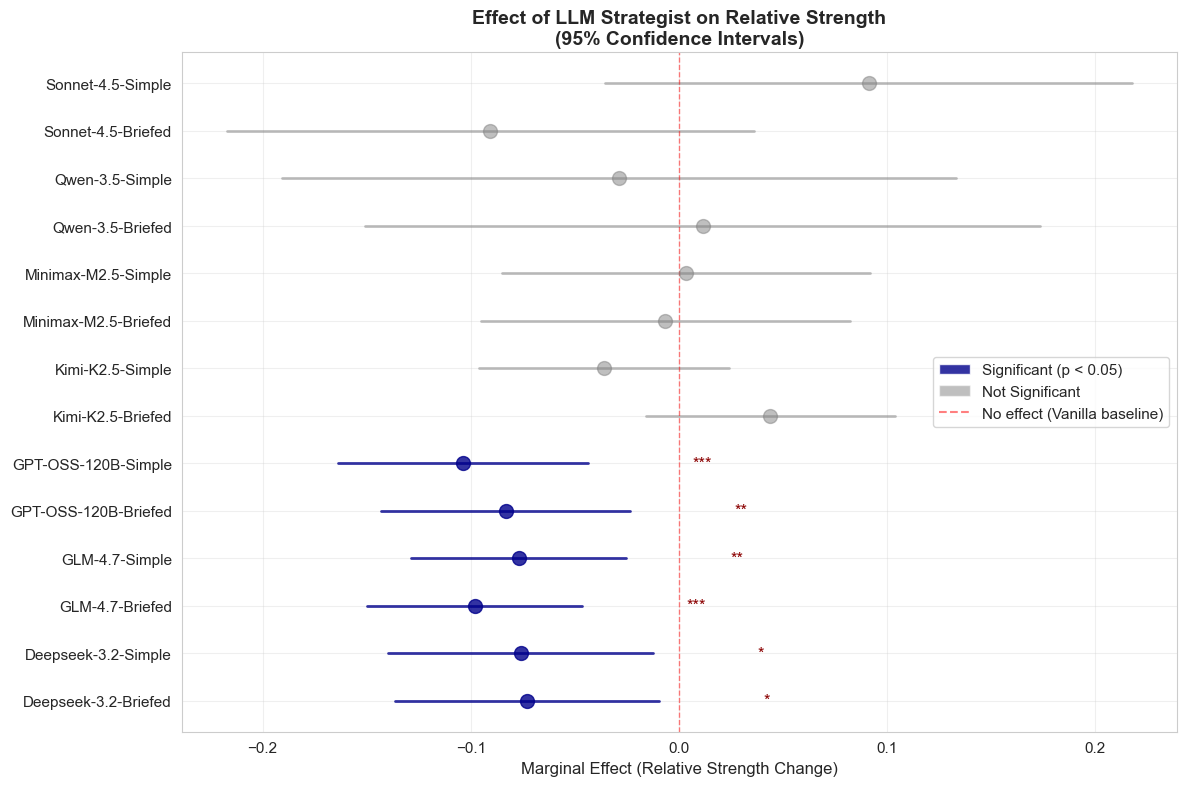

In [29]:
# =====================================================
# VISUALIZATION 1: LLM STRATEGIST EFFECTS
# =====================================================
# Create forest plot showing how LLM strategists affect score ratio
# compared to vanilla gameplay (no LLM strategist)

# Create forest plot for conditions with integrated summary
fig, ax = plot_forest_plot(
    condition_df, 
    title='Effect of LLM Strategist on Relative Strength\n(95% Confidence Intervals)',
    xlabel='Marginal Effect (Relative Strength Change)',
    color='darkblue',
    figsize=(12, 8),
    reference_line_label='No effect (Vanilla baseline)',
    use_prob_scale=False,  # Use raw scale for score ratio
    sort_alphabetically=True
)

plt.show()


Civilization Effects on Relative Strength
(Relative to Mean, 95% Confidence Intervals) SUMMARY

Baseline: Average of all civilization effect

Statistically Significant Effects (p < 0.05):
----------------------------------------
  Mongolia                       -0.194 [-0.266, -0.122] ***
  Assyria                        -0.168 [-0.238, -0.097] ***
  Japan                          -0.158 [-0.224, -0.092] ***
  Persia                         -0.154 [-0.219, -0.089] ***
  Denmark                        -0.147 [-0.219, -0.076] ***
  Rome                           -0.144 [-0.213, -0.074] ***
  America                        -0.139 [-0.206, -0.073] ***
  England                        -0.119 [-0.198, -0.040] **
  Korea                          -0.106 [-0.181, -0.030] **
  Sweden                         -0.083 [-0.159, -0.006] *
  The Huns                       -0.079 [-0.149, -0.009] *
  Spain                          +0.083 [+0.015, +0.151] *
  Siam                           +0.091 [+0.02

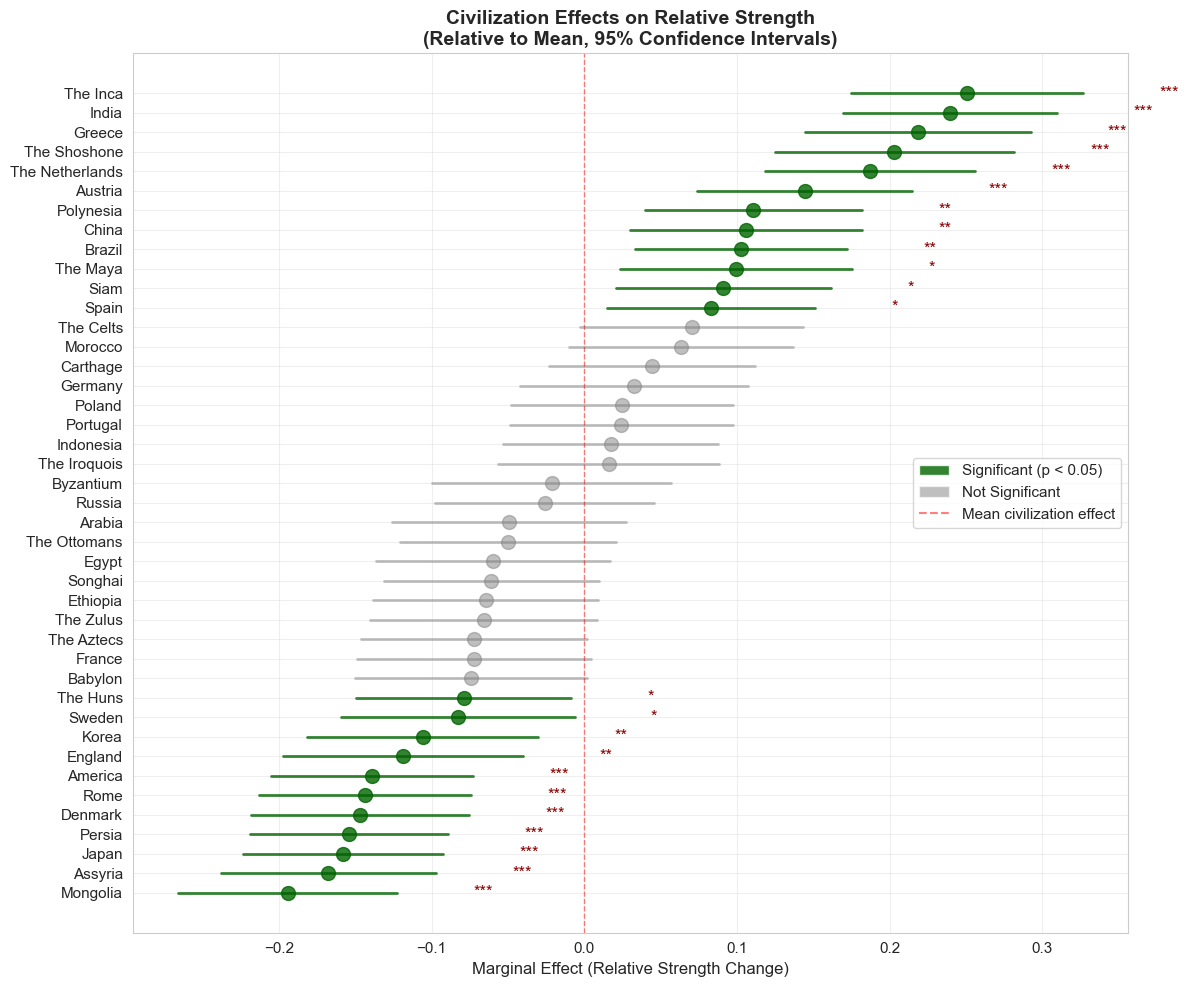

In [30]:
# =====================================================
# VISUALIZATION 2: CIVILIZATION EFFECTS (RELATIVE TO MEAN)
# =====================================================
# Create forest plot showing civilization strength relative to the mean
# This approach uses the average civilization performance as the baseline

# Create forest plot for civilizations with integrated summary
fig, ax = plot_forest_plot(
    civ_df,
    title='Civilization Effects on Relative Strength\n(Relative to Mean, 95% Confidence Intervals)',
    xlabel='Marginal Effect (Relative Strength Change)',
    color='darkgreen',
    figsize=(12, 10),
    reference_line_label='Mean civilization effect',
    use_prob_scale=False,  # Use raw scale for score ratio
)

plt.show()

In [31]:
# =====================================================
# CIVILIZATION FIXED EFFECTS: ADJUST FOR CIV ADVANTAGES
# =====================================================
# Extract civilization effects from the OLS model to adjust for civ advantages

# Create civilization effects lookup dictionary
civ_effects = {}
for var in civ_vars:
    # Extract civilization name from variable string
    # Format: "C(civilization, Sum)[S.CivName]"
    civ_name = var.split('[S.')[-1].rstrip(']')
    civ_effects[civ_name] = params[var]

# For the reference category (implied by Sum coding), calculate the negative sum
# Sum coding means all effects sum to zero
civ_effects['Venice'] = -sum(civ_effects.values())  # Venice is the missing civ

# Add adjusted_strength column to strength_df
# This removes the civilization advantage/disadvantage
strength_df['adjusted_strength'] = strength_df.apply(
    lambda row: row['relative_strength'] - civ_effects.get(row['civilization'], 0),
    axis=1
)
strength_df = strength_df[~strength_df['experiment'].isin(["observe-vanilla-standard"])]

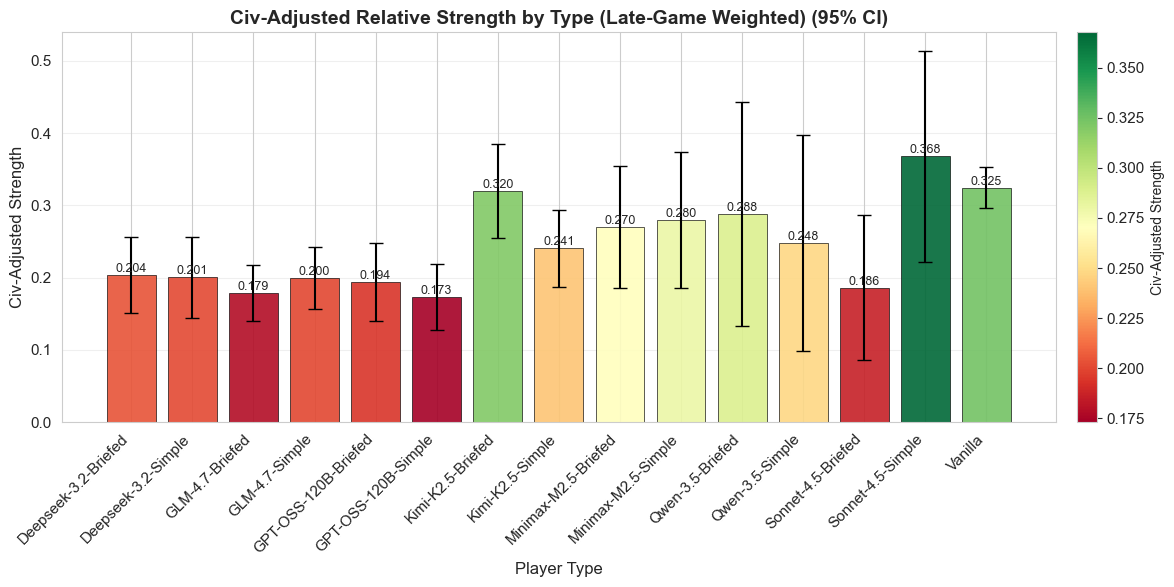

,Mean,Std,N
Deepseek-3.2-Briefed,0.203594,0.289715,115
Deepseek-3.2-Simple,0.200529,0.304980,115
GLM-4.7-Briefed,0.178552,0.265696,179
GLM-4.7-Simple,0.199706,0.289252,179
GPT-OSS-120B-Briefed,0.193515,0.313560,130
GPT-OSS-120B-Simple,0.172948,0.267281,130
Kimi-K2.5-Briefed,0.320490,0.378593,130
Kimi-K2.5-Simple,0.240606,0.312508,130
Minimax-M2.5-Briefed,0.270140,0.325279,58
Minimax-M2.5-Simple,0.279824,0.362905,58


In [32]:
# Plot bar chart of average weighted strength by player type
plot_bar_chart(
    strength_df,
    category_col='player_type',
    value_col='adjusted_strength',
    use_percentage=False,
    xlabel='Player Type',
    ylabel='Civ-Adjusted Strength',
    title='Civ-Adjusted Relative Strength by Type (Late-Game Weighted)',
    show_error_bars=True,
    confidence_level=0.95,
    value_format='{:.3f}',
    rotation=45,
    colormap='RdYlGn',
    figsize=(12, 6)
)

In [33]:
# =====================================================
# RATING CALCULATION: USING OPENSKILL
# =====================================================
# Calculate player ratings using OpenSkill's BradleyTerryFull model
# with batch iterative fitting (order-independent)

from rating_system import calculate_ratings, compare_with_ols

# Calculate ratings with batch iterative fitting
rating_summary_df = calculate_ratings(
    strength_df,
    initial_mu=25.0,
    initial_sigma=8.33,
    verbose=True
)

CALCULATING RATINGS USING OPENSKILL (RANDOM-ORDER AVERAGING)

Model: PlackettLuce (rank-based)
Initial rating: μ=25.0, σ=8.33
Number of runs: 100
Total games: 247

Processing 100 random orderings...
  Completed 10/100 runs...
  Completed 20/100 runs...
  Completed 30/100 runs...
  Completed 40/100 runs...
  Completed 50/100 runs...
  Completed 60/100 runs...
  Completed 70/100 runs...
  Completed 80/100 runs...
  Completed 90/100 runs...
  Completed 100/100 runs...

✓ Random-order averaging complete!

RATING SUMMARY
Rank   Player Type               Rating (μ)      Sigma        Elo       
----------------------------------------------------------------------------
1      Sonnet-4.5-Simple                   28.52        4.918       1643
2      Qwen-3.5-Briefed                    29.18        6.003       1639
3      Qwen-3.5-Simple                     25.58        6.084       1519
4      Minimax-M2.5-Simple                 25.39        4.245       1518
5      Kimi-K2.5-Briefed            

VALIDATION: OPENSKILL RATINGS vs OLS COEFFICIENTS

Comparison of ranking methods:

Player Type               Rank     Rating Dev   OLS Coef    
---------------------------------------------------------
Qwen-3.5-Briefed          1              4.18       0.0115
Sonnet-4.5-Simple         2              3.52       0.0911
Qwen-3.5-Simple           3              0.58      -0.0289
Minimax-M2.5-Simple       4              0.39       0.0032
Kimi-K2.5-Briefed         5              0.08       0.0439
Vanilla                   6              0.00       0.0000
Minimax-M2.5-Briefed      7             -2.08      -0.0065
Deepseek-3.2-Briefed      8             -2.81      -0.0730
Kimi-K2.5-Simple          9             -3.00      -0.0360
GLM-4.7-Simple            10            -3.73      -0.0769
GLM-4.7-Briefed           11            -4.36      -0.0981
GPT-OSS-120B-Simple       12            -4.39      -0.1037
Sonnet-4.5-Briefed        13            -5.05      -0.0906
GPT-OSS-120B-Briefed      14   

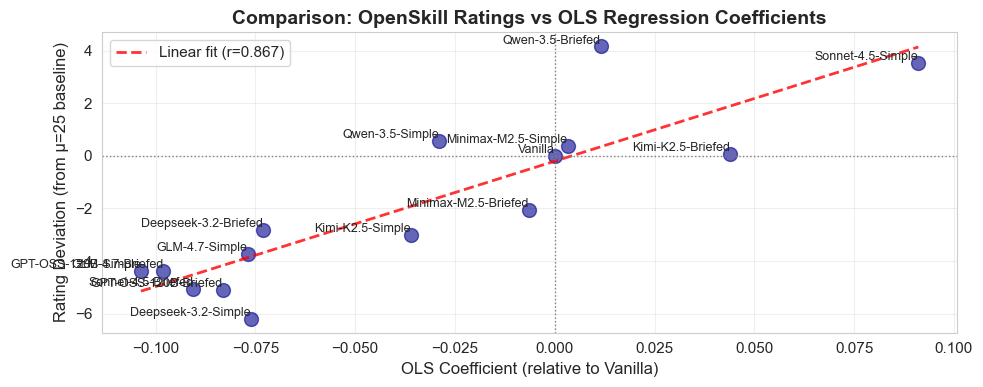

In [34]:
# =====================================================
# VALIDATION: RATING vs OLS COMPARISON
# =====================================================
# Compare OpenSkill ratings to OLS regression coefficients

comparison_df = compare_with_ols(rating_summary_df, model, baseline_type='Vanilla', baseline_rating=25.0, verbose=True)

# Scatter plot visualization
valid_comparison = comparison_df.dropna()
if len(valid_comparison) > 1:
    correlation = valid_comparison['rating_deviation'].corr(valid_comparison['ols_coefficient'])
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(valid_comparison['ols_coefficient'], valid_comparison['rating_deviation'], 
               s=100, alpha=0.6, color='darkblue')
    
    # Add labels for each point
    for _, row in valid_comparison.iterrows():
        ax.annotate(row['player_type'], 
                   (row['ols_coefficient'], row['rating_deviation']),
                   fontsize=9, ha='right', va='bottom')
    
    # Add trend line
    z = np.polyfit(valid_comparison['ols_coefficient'], valid_comparison['rating_deviation'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid_comparison['ols_coefficient'].min(), 
                        valid_comparison['ols_coefficient'].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label=f'Linear fit (r={correlation:.3f})')
    
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.axvline(0, color='gray', linestyle=':', linewidth=1)
    
    ax.set_xlabel('OLS Coefficient (relative to Vanilla)', fontsize=12)
    ax.set_ylabel('Rating Deviation (from μ=25 baseline)', fontsize=12)
    ax.set_title('Comparison: OpenSkill Ratings vs OLS Regression Coefficients', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

HEAD-TO-HEAD MATCHUP MATRIX (EMPIRICAL)

Matrix dimensions: 15x15
Player types: 15
Total games analyzed: 247

Interpretation:
  - Rows: Player A
  - Columns: Player B
  - Value: Empirical P(A has higher adjusted strength than B)
  - P-values: One-way ANOVA testing if mean strengths differ

Sample sizes:
  Deepseek-3.2-Briefed vs Vanilla: 230 matchups
  Deepseek-3.2-Simple vs Vanilla: 230 matchups
  GLM-4.7-Briefed vs Vanilla: 498 matchups
  GLM-4.7-Simple vs Vanilla: 498 matchups
  GPT-OSS-120B-Briefed vs Vanilla: 420 matchups
  GPT-OSS-120B-Simple vs Vanilla: 420 matchups
  Kimi-K2.5-Briefed vs Vanilla: 260 matchups
  Kimi-K2.5-Simple vs Vanilla: 260 matchups
  Minimax-M2.5-Briefed vs Vanilla: 116 matchups
  Minimax-M2.5-Simple vs Vanilla: 116 matchups
  Qwen-3.5-Briefed vs Vanilla: 34 matchups
  Qwen-3.5-Simple vs Vanilla: 34 matchups
  Sonnet-4.5-Briefed vs Vanilla: 92 matchups
  Sonnet-4.5-Simple vs Vanilla: 92 matchups


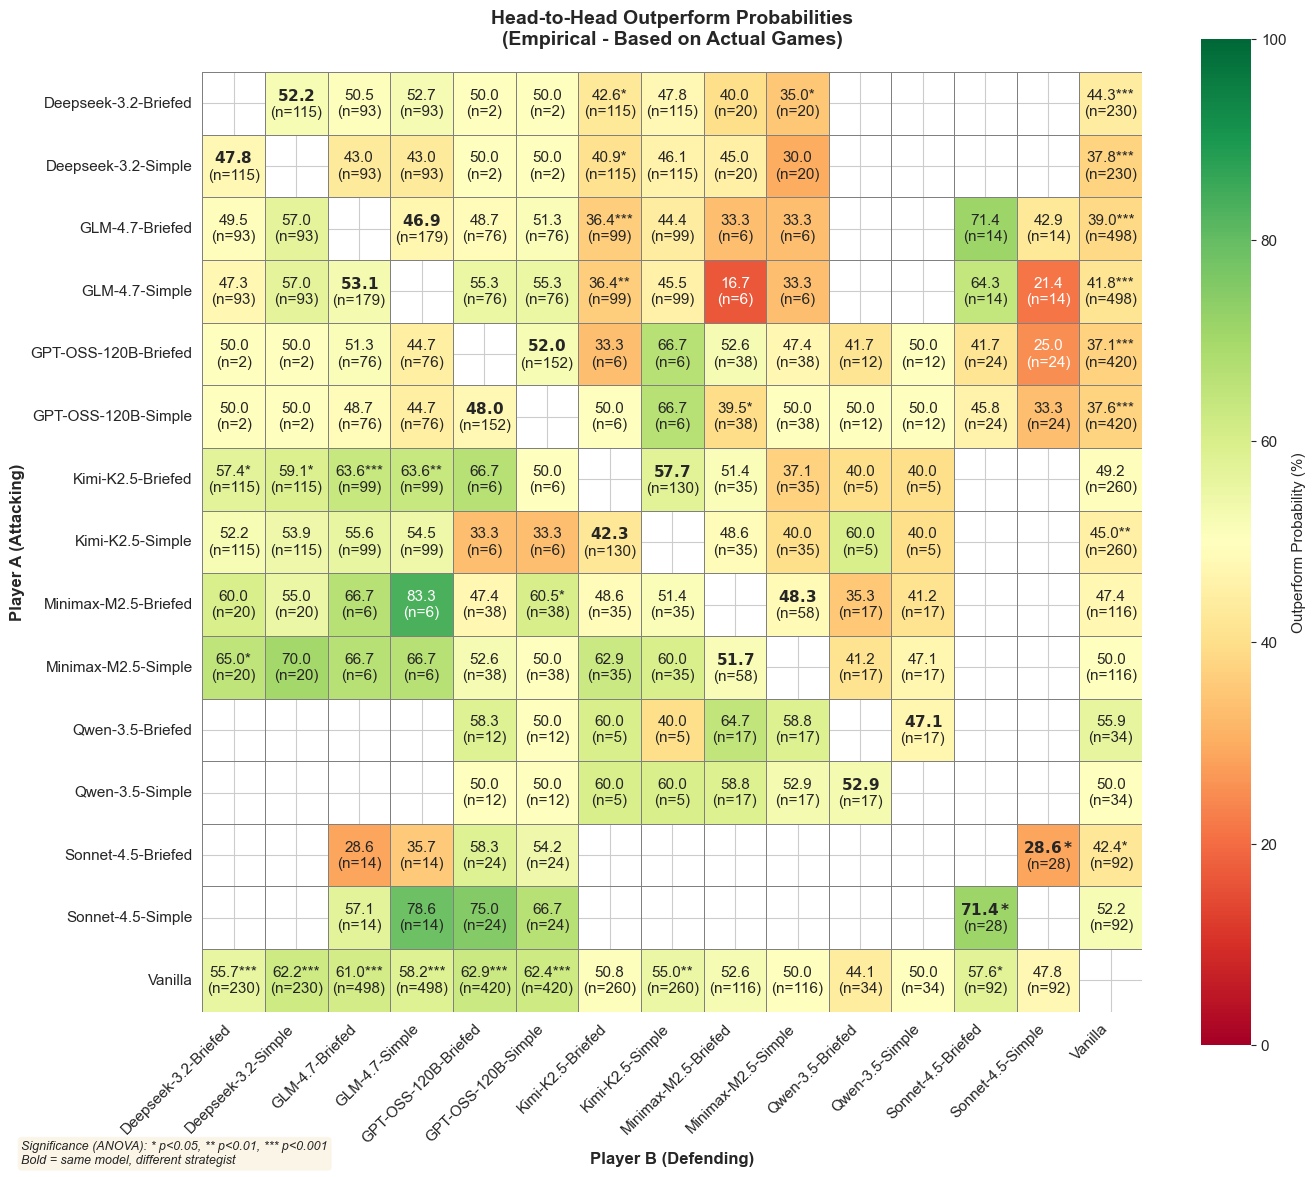


MATCHUP ANALYSIS

Deepseek-3.2-Briefed:
  vs Vanilla: 44.3% (n=230)
  Best matchup: vs GLM-4.7-Simple (52.7%, n=93)
  Worst matchup: vs Minimax-M2.5-Simple (35.0%, n=20)

Deepseek-3.2-Simple:
  vs Vanilla: 37.8% (n=230)
  Best matchup: vs GPT-OSS-120B-Briefed (50.0%, n=2)
  Worst matchup: vs Minimax-M2.5-Simple (30.0%, n=20)

GLM-4.7-Briefed:
  vs Vanilla: 39.0% (n=498)
  Best matchup: vs Sonnet-4.5-Briefed (71.4%, n=14)
  Worst matchup: vs Minimax-M2.5-Briefed (33.3%, n=6)

GLM-4.7-Simple:
  vs Vanilla: 41.8% (n=498)
  Best matchup: vs Sonnet-4.5-Briefed (64.3%, n=14)
  Worst matchup: vs Minimax-M2.5-Briefed (16.7%, n=6)

GPT-OSS-120B-Briefed:
  vs Vanilla: 37.1% (n=420)
  Best matchup: vs Kimi-K2.5-Simple (66.7%, n=6)
  Worst matchup: vs Sonnet-4.5-Simple (25.0%, n=24)

GPT-OSS-120B-Simple:
  vs Vanilla: 37.6% (n=420)
  Best matchup: vs Kimi-K2.5-Simple (66.7%, n=6)
  Worst matchup: vs Sonnet-4.5-Simple (33.3%, n=24)

Kimi-K2.5-Briefed:
  vs Vanilla: 49.2% (n=260)
  Best matchup: vs

In [35]:
# =====================================================
# HEAD-TO-HEAD MATCHUP MATRIX
# =====================================================
# Calculate empirical pairwise outperform probabilities between all player types
# based on actual game data

from rating_system import create_matchup_matrix
from plot_utilities import plot_matchup_heatmap

# Create matchup matrix using actual game data from strength_df
matchup_matrix_df, count_matrix_df, pvalue_matrix_df = create_matchup_matrix(
    strength_df,
    verbose=True
)

# Visualize as heatmap with percentages and match counts
fig, ax = plot_matchup_heatmap(
    matchup_matrix_df,
    count_df=count_matrix_df,
    pvalue_df=pvalue_matrix_df,
    title="Head-to-Head Outperform Probabilities\n(Empirical - Based on Actual Games)",
    figsize=(14, 12),
    as_percentage=True
)

plt.show()

# Matchup analysis with Vanilla baseline
print("\n" + "=" * 60)
print("MATCHUP ANALYSIS")
print("=" * 60)

for player in matchup_matrix_df.index:
    if player == 'Vanilla':
        continue  # Skip baseline
    
    # Find best matchup (highest outperform probability against non-self)
    matchups = matchup_matrix_df.loc[player]
    matchups_filtered = matchups[matchups.index != player].dropna()
    
    if len(matchups_filtered) == 0:
        continue
    
    best_opponent = matchups_filtered.idxmax()
    best_prob = matchups_filtered.max()
    best_count = count_matrix_df.loc[player, best_opponent]
    
    worst_opponent = matchups_filtered.idxmin()
    worst_prob = matchups_filtered.min()
    worst_count = count_matrix_df.loc[player, worst_opponent]
    
    # Get matchup vs Vanilla
    vanilla_prob = matchup_matrix_df.loc[player, 'Vanilla']
    vanilla_count = count_matrix_df.loc[player, 'Vanilla']
    
    print(f"\n{player}:")
    if pd.notna(vanilla_prob):
        print(f"  vs Vanilla: {vanilla_prob*100:.1f}% (n={int(vanilla_count)})")
    else:
        print(f"  vs Vanilla: No data")
    print(f"  Best matchup: vs {best_opponent} ({best_prob*100:.1f}%, n={int(best_count)})")
    print(f"  Worst matchup: vs {worst_opponent} ({worst_prob*100:.1f}%, n={int(worst_count)})")


CIV-ADJUSTED WIN PROBABILITY: VALIDATION

Original mean: 0.1250
Adjusted mean: 0.1268

Original std: 0.1737
Adjusted std: 0.1805

Adjustment range: [-0.1943, 0.2508]
Mean adjustment magnitude: 0.1003


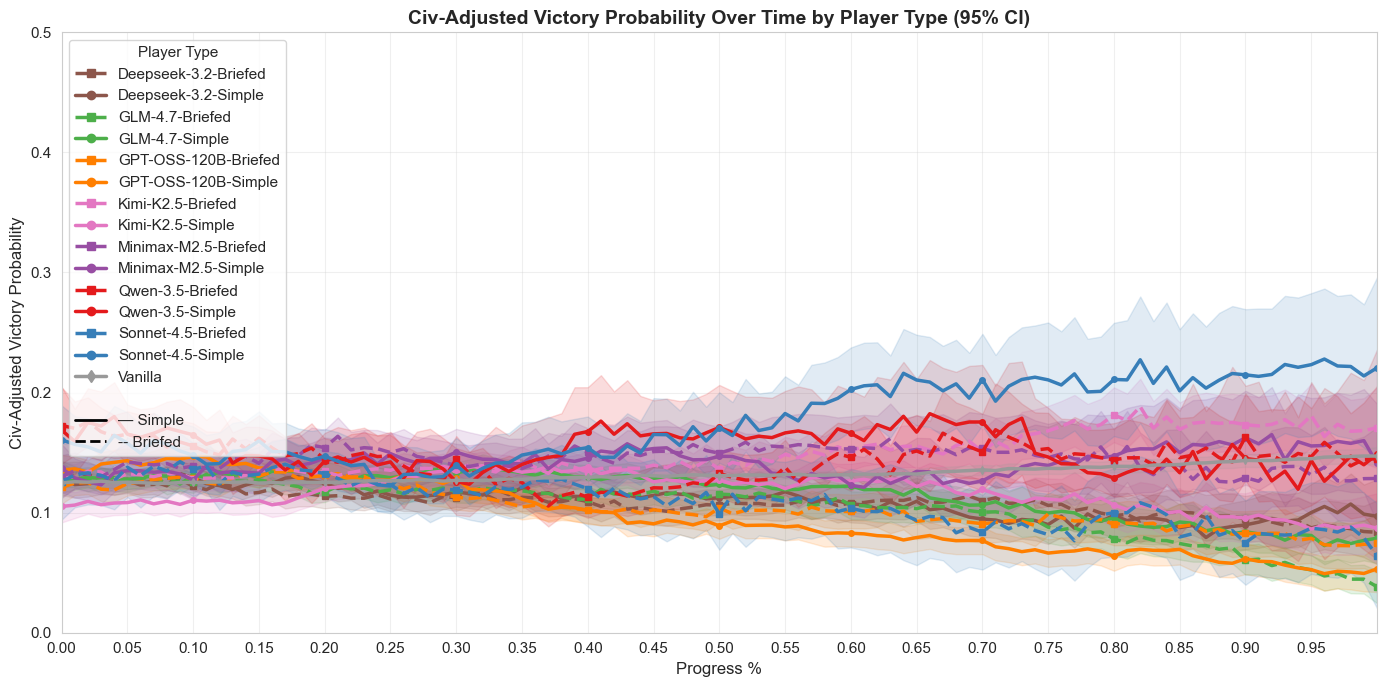

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,49080,0.108,0.163,-0.240,1.064,-0.031280,-0.055
Deepseek-3.2-Simple,49080,0.110,0.175,-0.251,1.153,-0.039355,-0.065
GLM-4.7-Briefed,75725,0.103,0.155,-0.246,1.066,-0.074444,-0.139
GLM-4.7-Simple,75725,0.116,0.166,-0.251,1.077,-0.059114,-0.103
GPT-OSS-120B-Briefed,54736,0.104,0.169,-0.251,1.043,-0.054747,-0.094
GPT-OSS-120B-Simple,54736,0.096,0.138,-0.240,1.046,-0.102623,-0.214
Kimi-K2.5-Briefed,55451,0.149,0.199,-0.251,1.157,0.053355,0.078
Kimi-K2.5-Simple,55451,0.116,0.178,-0.240,1.115,-0.020836,-0.034
Minimax-M2.5-Briefed,24508,0.145,0.189,-0.239,0.979,-0.005379,-0.008
Minimax-M2.5-Simple,24508,0.142,0.213,-0.240,1.026,0.015277,0.021


In [36]:
# =====================================================
# CIV-ADJUSTED VICTORY PROBABILITY OVER TIME
# =====================================================
# Apply civilization adjustments (from Cell 12) to predicted_win_probability
# and visualize how player types perform when civilization bias is removed

# Apply the same civ_effects from Cell 12 to predicted_win_probability
turn_df['civ_adjusted_win_prob'] = turn_df.apply(
    lambda row: row['predicted_win_probability'] - civ_effects.get(row['civilization'], 0),
    axis=1
)

# Validation checks
print("\n" + "=" * 60)
print("CIV-ADJUSTED WIN PROBABILITY: VALIDATION")
print("=" * 60)
print(f"\nOriginal mean: {turn_df['predicted_win_probability'].mean():.4f}")
print(f"Adjusted mean: {turn_df['civ_adjusted_win_prob'].mean():.4f}")
print(f"\nOriginal std: {turn_df['predicted_win_probability'].std():.4f}")
print(f"Adjusted std: {turn_df['civ_adjusted_win_prob'].std():.4f}")

adjustment_range = turn_df['predicted_win_probability'] - turn_df['civ_adjusted_win_prob']
print(f"\nAdjustment range: [{adjustment_range.min():.4f}, {adjustment_range.max():.4f}]")
print(f"Mean adjustment magnitude: {adjustment_range.abs().mean():.4f}")

# Plot civ-adjusted win probability over time
fig, ax = plot_metric_over_time(
    turn_df,
    metric_calculation=lambda df: df['civ_adjusted_win_prob'],
    title="Civ-Adjusted Victory Probability Over Time by Player Type",
    ylabel="Civ-Adjusted Victory Probability",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, 0.5)
)